# 07 — Gelişmiş Analiz

**Girdi:** `data/csv/featured_dataset.csv` ve `data/csv/cleaned_dataset.csv`  
**Çıktılar:** `data/model_outputs/` ve `data/plots/` altında metrikler ve görseller

## Bu Notebook'ta Yapılanlar

| Görev | Konu | Açıklama |
|-------|------|----------|
| 1 | Augmentation Karşılaştırması | Örnekleme öncesi/sonrası Macro F1 & Recall |
| 2 | Feature Engineering Karşılaştırması | Ham vs. seçilmiş özellik seti performansı |
| 3 | Feature Importance Analizi | Modellerin en önemli ilk 15–20 özelliğini çıkar ve görselleştir |
| 4 | XGBoost + CatBoost + RF | 3 modeli Stratified K-Fold ile karşılaştır |

### ⚠️ RAM Optimizasyon Kuralları
- Tüm model eğitimlerinde `n_jobs=2`  
- `cross_validate` çağrılarında `n_jobs=1`  
- Eğitim matrislerinde `X.astype(np.float32)`  
- Kullanılmayan büyük DataFrame'ler için `del` + `gc.collect()`

In [1]:
# ── Kütüphane Kurulumu ────────────────────────────────────────────────────────
# imbalanced-learn, xgboost, catboost yoksa kur
import subprocess, sys

def pip_install(pkg, import_name=None):
    """Paketi kur (zaten kuruluysa atla)."""
    try:
        __import__(import_name or pkg.split('[')[0].replace('-','_'))
    except ImportError:
        print(f"Kuruluyor: {pkg}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
        print(f"✓ {pkg} kuruldu")

pkgs = [
    ("imbalanced-learn", "imblearn"),
    ("xgboost", "xgboost"),
    ("catboost", "catboost"),
]
for pkg, import_name in pkgs:
    pip_install(pkg, import_name=import_name)

print("\n✓ Tüm bağımlılıklar hazır")


✓ Tüm bağımlılıklar hazır


In [ ]:
# ── Genel Import'lar ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import gc
import time
import warnings

warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report,
    f1_score, accuracy_score, recall_score,
    make_scorer
)

RANDOM_STATE = 42
os.makedirs('../data/model_outputs', exist_ok=True)
os.makedirs('../data/plots', exist_ok=True)

# ── Yol Sabitleri (tüm notebook boyunca kullanılır) ───────────────────────────
FEATURED_PATH  = "../data/csv/featured_dataset.csv"
CLEANED_PATH   = "../data/csv/cleaned_dataset.csv"
COMBINED_PATH  = "../data/csv/combined_dataset.csv"
FEATURES_TXT   = "../data/csv/selected_features.txt"
LABEL_MAP_PATH = "../data/csv/label_mapping.csv"

with open(FEATURES_TXT) as f:
    FEATURE_COLS = [line.strip() for line in f if line.strip()]

label_mapping = pd.read_csv(LABEL_MAP_PATH)
INT_TO_LABEL  = dict(zip(label_mapping["label_int"], label_mapping["label_string"]))
LABEL_TO_INT  = {label: label_int for label_int, label in INT_TO_LABEL.items()}
LABEL_NAMES   = [INT_TO_LABEL[i] for i in sorted(INT_TO_LABEL)]

print("=" * 50)
print("Kütüphaneler yüklendi ✓")
print(f"  Seçilmiş özellik sayısı : {len(FEATURE_COLS)}")
print(f"  Sınıf sayısı            : {len(INT_TO_LABEL)}")
print("=" * 50)

Kütüphaneler yüklendi ✓
  Seçilmiş özellik sayısı : 47
  Sınıf sayısı            : 12


---
## Görev 1 — Veri Artırma (Augmentation) Öncesi vs. Sonrası

**Amaç:** 01 notebookunda hazırlanmış `combined_dataset.csv` çıktısı ile
`cleaned_dataset.csv` arasındaki farkı, aynı model ailesi üzerinde karşılaştırmak;
burada yeniden oversampling üretmemek.

| Senaryo | Veri Kaynağı | Beklenti |
|---------|-------------|----------|
| **Önce** | `cleaned_dataset.csv` | Azınlık sınıflarında düşük Recall |
| **Sonra** | `combined_dataset.csv` | Azınlık Recall ve Macro F1 yükselir |

In [3]:
# ── 1a. Veriyi Yükle ──────────────────────────────────────────────────────────
print("Featured dataset yükleniyor...")
df_feat = pd.read_csv(FEATURED_PATH, low_memory=False)

X_all = df_feat[FEATURE_COLS].values.astype(np.float32)   # RAM optimizasyonu
y_all = df_feat["label_multiclass"].values

print(f"  Satır       : {X_all.shape[0]:,}")
print(f"  Özellik     : {X_all.shape[1]}")
print(f"  Bellek (X)  : {X_all.nbytes / 1024**2:.1f} MB  (float32)")
print()

# Sınıf dağılımını göster
print("Sınıf dağılımı (eğitim öncesi):")
unique, counts = np.unique(y_all, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  [{cls:2d}] {INT_TO_LABEL[cls]:<35} {cnt:>7,}")

Featured dataset yükleniyor...
  Satır       : 495,855
  Özellik     : 47
  Bellek (X)  : 88.9 MB  (float32)

Sınıf dağılımı (eğitim öncesi):
  [ 0] BENIGN                              383,341
  [ 1] Bot                                   1,948
  [ 2] DDoS                                 29,998
  [ 3] DoS GoldenEye                        10,286
  [ 4] DoS Hulk                             22,915
  [ 5] DoS Slowhttptest                      5,228
  [ 6] DoS slowloris                         5,384
  [ 7] FTP-Patator                           5,931
  [ 8] PortScan                             25,483
  [ 9] SSH-Patator                           3,219
  [10] Web Attack - Brute Force              1,470
  [11] Web Attack - XSS                        652


In [4]:
# ── 1b. Train/Test Split ──────────────────────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_all
)

print(f"Train: {len(X_tr):>8,} satır")
print(f"Test : {len(X_te):>8,} satır")

Train:  396,684 satır
Test :   99,171 satır


In [ ]:
# ── 1c. AUGMENTATION ÖNCESİ ───────────────────────────────────────────────────
# cleaned_dataset.csv: 01 notebookundan önceki temizlenmiş ama dengelenmemiş veri
print("[ÖNCE] RF eğitiliyor (cleaned_dataset.csv)...")
t0 = time.time()

df_before = pd.read_csv(CLEANED_PATH, low_memory=False)
meta_cols_before = {"Label", "source_file", "label_multiclass", "label_binary"}
feat_cols_before = [
    c for c in df_before.select_dtypes(include=[np.number]).columns
    if c not in meta_cols_before
]

if "label_multiclass" not in df_before.columns:
    df_before["label_multiclass"] = df_before["Label"].astype(str).str.strip().map(LABEL_TO_INT)

X_before = df_before[feat_cols_before].values.astype(np.float32)
y_before = df_before["label_multiclass"].values

X_tr_before, X_te_before, y_tr_before, y_te_before = train_test_split(
    X_before, y_before,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_before
)

rf_before = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    class_weight=None,          # karşılaştırma için dengeleme yok
    n_jobs=2,                   # RAM kuralı
    random_state=RANDOM_STATE
)
rf_before.fit(X_tr_before, y_tr_before)

t_before = time.time() - t0
y_pred_before = rf_before.predict(X_te_before)

acc_before    = accuracy_score(y_te_before, y_pred_before)
f1mac_before  = f1_score(y_te_before, y_pred_before, average="macro",    zero_division=0)
f1wt_before   = f1_score(y_te_before, y_pred_before, average="weighted", zero_division=0)

print(f"  Eğitim süresi  : {t_before:.1f} s")
print(f"  Accuracy       : {acc_before:.4f}")
print(f"  Macro F1       : {f1mac_before:.4f}")
print(f"  Weighted F1    : {f1wt_before:.4f}")

report_before = classification_report(
    y_te_before, y_pred_before,
    target_names=LABEL_NAMES,
    output_dict=True,
    zero_division=0
)
print("\nPer-class F1 ve Recall (ÖNCE):")
for cls_name in LABEL_NAMES:
    if cls_name in report_before:
        r = report_before[cls_name]
        print(f"  {cls_name:<35}  F1={r['f1-score']:.3f}  Recall={r['recall']:.3f}  Support={int(r['support'])}")

del rf_before, df_before, X_before, y_before, X_tr_before, X_te_before, y_tr_before, y_te_before
gc.collect()
print("\n✓ Bellek temizlendi")

[ÖNCE] RF eğitiliyor (class_weight=None, augmentation yok)...
  Eğitim süresi  : 81.5 s
  Accuracy       : 0.9963
  Macro F1       : 0.9108
  Weighted F1    : 0.9963

Per-class F1 ve Recall (ÖNCE):
  BENIGN                               F1=0.999  Recall=0.999  Support=76668
  Bot                                  F1=0.872  Recall=0.877  Support=390
  DDoS                                 F1=0.999  Recall=0.999  Support=6000
  DoS GoldenEye                        F1=0.997  Recall=0.996  Support=2057
  DoS Hulk                             F1=0.996  Recall=0.995  Support=4583
  DoS Slowhttptest                     F1=0.996  Recall=0.994  Support=1046
  DoS slowloris                        F1=0.996  Recall=0.994  Support=1077
  FTP-Patator                          F1=1.000  Recall=1.000  Support=1186
  PortScan                             F1=0.996  Recall=0.995  Support=5096
  SSH-Patator                          F1=0.999  Recall=0.998  Support=644
  Web Attack - Brute Force             F1=0

In [ ]:
# ── 1d. AUGMENTATION SONRASI ──────────────────────────────────────────────────
# combined_dataset.csv: 01 notebookunda hazırlanmış, daha dengeli veri
print("[SONRA] RF eğitiliyor (combined_dataset.csv)...")
t0 = time.time()

df_after = pd.read_csv(COMBINED_PATH, low_memory=False)
meta_cols_after = {"Label", "source_file", "label_multiclass", "label_binary"}
feat_cols_after = [
    c for c in df_after.select_dtypes(include=[np.number]).columns
    if c not in meta_cols_after
]

if "label_multiclass" not in df_after.columns:
    df_after["label_multiclass"] = df_after["Label"].astype(str).str.strip().map(LABEL_TO_INT)

X_after = df_after[feat_cols_after].values.astype(np.float32)
y_after = df_after["label_multiclass"].values

X_tr_after, X_te_after, y_tr_after, y_te_after = train_test_split(
    X_after, y_after,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_after
)

rf_after = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    class_weight=None,
    n_jobs=2,
    random_state=RANDOM_STATE
)
rf_after.fit(X_tr_after, y_tr_after)

t_after = time.time() - t0
y_pred_after = rf_after.predict(X_te_after)

acc_after    = accuracy_score(y_te_after, y_pred_after)
f1mac_after  = f1_score(y_te_after, y_pred_after, average="macro",    zero_division=0)
f1wt_after   = f1_score(y_te_after, y_pred_after, average="weighted", zero_division=0)

print(f"  Eğitim süresi  : {t_after:.1f} s")
print(f"  Accuracy       : {acc_after:.4f}")
print(f"  Macro F1       : {f1mac_after:.4f}")
print(f"  Weighted F1    : {f1wt_after:.4f}")

report_after = classification_report(
    y_te_after, y_pred_after,
    target_names=LABEL_NAMES,
    output_dict=True,
    zero_division=0
)
print("\nPer-class F1 ve Recall (SONRA):")
for cls_name in LABEL_NAMES:
    if cls_name in report_after:
        r = report_after[cls_name]
        print(f"  {cls_name:<35}  F1={r['f1-score']:.3f}  Recall={r['recall']:.3f}")

del rf_after, df_after, X_after, y_after, X_tr_after, X_te_after, y_tr_after, y_te_after
gc.collect()
print("\n✓ Bellek temizlendi")

Oversampling stratejisi:
  [1] Bot                                  1,558 → 10,000
  [3] DoS GoldenEye                        8,229 → 10,000
  [5] DoS Slowhttptest                     4,182 → 10,000
  [6] DoS slowloris                        4,307 → 10,000
  [7] FTP-Patator                          4,745 → 10,000
  [9] SSH-Patator                          2,575 → 10,000
  [10] Web Attack - Brute Force             1,176 → 10,000
  [11] Web Attack - XSS                       522 → 10,000

Eğitim seti: 396,684 → 449,390 satır (augmentation sonrası)
Bellek (X_tr_aug): 80.6 MB


In [ ]:
# ── 1e. AUGMENTATION SONRASI ──────────────────────────────────────────────────
print("[SONRA] RF eğitiliyor (önceden hazırlanmış augmented veri)...")
t0 = time.time()

rf_after = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    class_weight=None,
    n_jobs=2,
    random_state=RANDOM_STATE
)
rf_after.fit(X_tr_aug, y_tr_aug)

t_after = time.time() - t0
y_pred_after = rf_after.predict(X_te)

acc_after    = accuracy_score(y_te, y_pred_after)
f1mac_after  = f1_score(y_te, y_pred_after, average="macro",    zero_division=0)
f1wt_after   = f1_score(y_te, y_pred_after, average="weighted", zero_division=0)

print(f"  Eğitim süresi  : {t_after:.1f} s")
print(f"  Accuracy       : {acc_after:.4f}")
print(f"  Macro F1       : {f1mac_after:.4f}")
print(f"  Weighted F1    : {f1wt_after:.4f}")

report_after = classification_report(
    y_te, y_pred_after,
    target_names=LABEL_NAMES,
    output_dict=True,
    zero_division=0
)
print("\nPer-class F1 ve Recall (SONRA):")
for cls_name in LABEL_NAMES:
    if cls_name in report_after:
        r = report_after[cls_name]
        print(f"  {cls_name:<35}  F1={r['f1-score']:.3f}  Recall={r['recall']:.3f}")

del rf_after, X_tr_aug, y_tr_aug
gc.collect()
print("\n✓ Bellek temizlendi")

[SONRA] RF eğitiliyor (RandomOverSampler ile augment edilmiş veri)...
  Eğitim süresi  : 68.4 s
  Accuracy       : 0.9964
  Macro F1       : 0.9089
  Weighted F1    : 0.9963

Per-class F1 ve Recall (SONRA):
  BENIGN                               F1=0.999  Recall=0.999
  Bot                                  F1=0.893  Recall=0.931
  DDoS                                 F1=0.999  Recall=0.999
  DoS GoldenEye                        F1=0.998  Recall=0.998
  DoS Hulk                             F1=0.996  Recall=0.995
  DoS Slowhttptest                     F1=0.997  Recall=0.995
  DoS slowloris                        F1=0.996  Recall=0.994
  FTP-Patator                          F1=1.000  Recall=1.000
  PortScan                             F1=0.995  Recall=0.995
  SSH-Patator                          F1=0.999  Recall=0.998
  Web Attack - Brute Force             F1=0.732  Recall=0.762
  Web Attack - XSS                     F1=0.303  Recall=0.269

✓ Bellek temizlendi


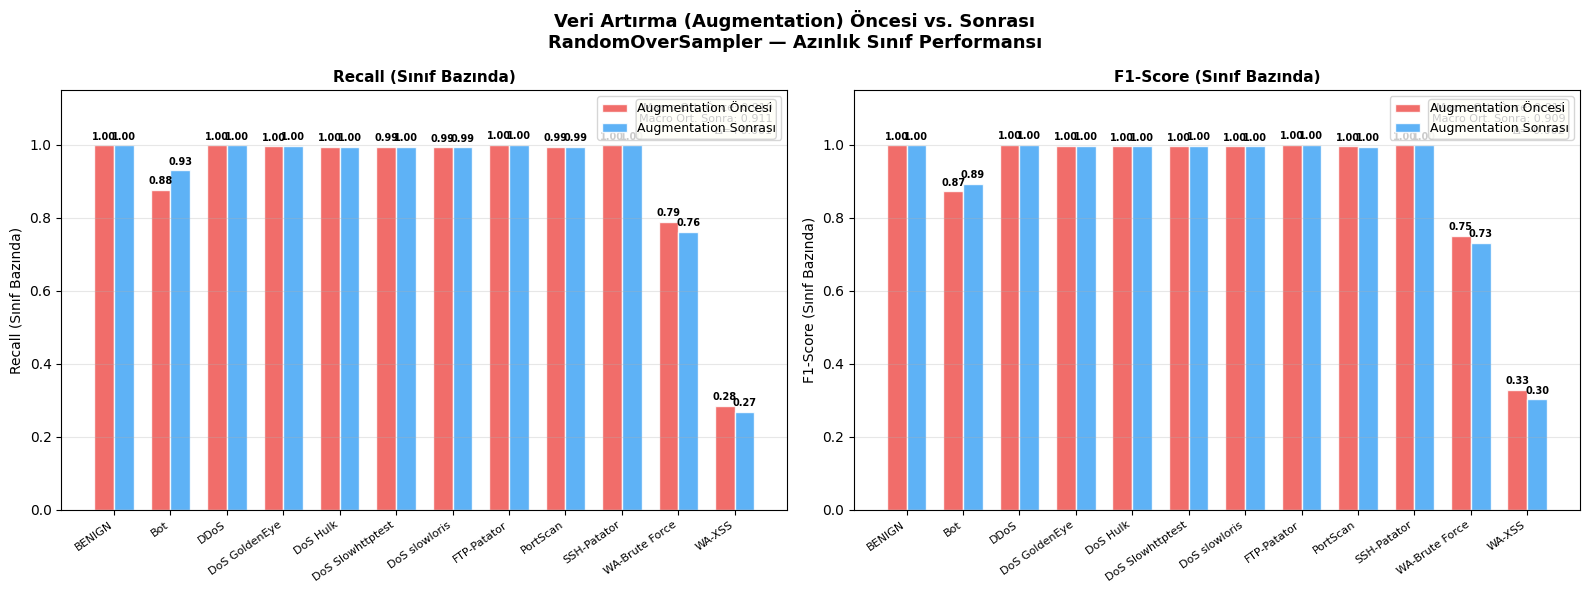

✓ Grafik kaydedildi: ../data/plots/gorev1_augmentation_comparison.png

AUGMENTATION ÖZET TABLOSU
  Metrik                     Önce      Sonra      Delta
  --------------------------------------------------
  Accuracy                 0.9963     0.9964    +0.0000
  Macro F1                 0.9108     0.9089    -0.0019
  Weighted F1              0.9963     0.9963    +0.0001


In [8]:
# ── 1f. Augmentation Karşılaştırma Grafikleri ─────────────────────────────────
classes_to_plot = [
    c for c in LABEL_NAMES
    if c in report_before and c in report_after
]

recalls_before = [report_before[c]['recall']   for c in classes_to_plot]
recalls_after  = [report_after[c]['recall']    for c in classes_to_plot]
f1s_before     = [report_before[c]['f1-score'] for c in classes_to_plot]
f1s_after      = [report_after[c]['f1-score']  for c in classes_to_plot]

x      = np.arange(len(classes_to_plot))
width  = 0.35
labels_short = [c.replace('Web Attack - ', 'WA-').replace('WorkingHours', '') for c in classes_to_plot]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Veri Artırma (Augmentation) Öncesi vs. Sonrası\n"
    "RandomOverSampler — Azınlık Sınıf Performansı",
    fontsize=13, fontweight="bold"
)

PALETTE = {"before": "#EF5350", "after": "#42A5F5"}

for ax, metric_before, metric_after, title in [
    (axes[0], recalls_before, recalls_after, "Recall (Sınıf Bazında)"),
    (axes[1], f1s_before,     f1s_after,     "F1-Score (Sınıf Bazında)")
]:
    b1 = ax.bar(x - width/2, metric_before, width,
                label="Augmentation Öncesi", color=PALETTE["before"], alpha=0.85, edgecolor="white")
    b2 = ax.bar(x + width/2, metric_after,  width,
                label="Augmentation Sonrası", color=PALETTE["after"],  alpha=0.85, edgecolor="white")

    # Değer etiketleri
    for bar in [*b1, *b2]:
        h = bar.get_height()
        if h > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.01,
                    f"{h:.2f}", ha='center', va='bottom', fontsize=7, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(labels_short, rotation=35, ha='right', fontsize=8)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel(title)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # Global metrik özeti (sağ üst)
    macro_b = np.mean(metric_before)
    macro_a = np.mean(metric_after)
    delta   = macro_a - macro_b
    sign    = "+" if delta >= 0 else ""
    ax.text(0.98, 0.97,
            f"Macro Ort. Önce: {macro_b:.3f}\nMacro Ort. Sonra: {macro_a:.3f}\nΔ={sign}{delta:.3f}",
            transform=ax.transAxes, va='top', ha='right', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
save_path = "../data/plots/gorev1_augmentation_comparison.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Grafik kaydedildi: {save_path}")

# Özet tablosu
print("\n" + "="*55)
print("AUGMENTATION ÖZET TABLOSU")
print("="*55)
print(f"  {'Metrik':<20} {'Önce':>10} {'Sonra':>10} {'Delta':>10}")
print(f"  {'-'*50}")
for name, b, a in [
    ("Accuracy",   acc_before,   acc_after),
    ("Macro F1",   f1mac_before, f1mac_after),
    ("Weighted F1",f1wt_before,  f1wt_after),
]:
    d = a - b
    sign = "+" if d >= 0 else ""
    print(f"  {name:<20} {b:>10.4f} {a:>10.4f} {sign+f'{d:.4f}':>10}")

---
## Görev 2 — Özellik Mühendisliği (Feature Engineering) Öncesi vs. Sonrası

**Amaç:** Korelasyon filtresi + MI filtresi uygulanmış (düşürülmüş boyutlu) veri ile
ham temizlenmiş veriyi karşılaştırarak:
- Eğitim süresinin nasıl azaldığını
- Model performansının nasıl değiştiğini

göstermek.

| Senaryo | Kaynak Dosya | Özellik Sayısı |
|---------|-------------|----------------|
| **Feature Engineering Öncesi** | `cleaned_dataset.csv` | ~60-75 ham özellik |
| **Feature Engineering Sonrası** | `featured_dataset.csv` | `selected_features.txt` kadarı |

In [9]:
# ── 2a. PRE-FE: Temizlenmiş Veriyi Yükle ─────────────────────────────────────
# cleaned_dataset.csv: korelasyon/MI filtresi uygulanmamış, tüm numerik özellikler
print("Cleaned dataset yükleniyor (pre-FE)...")
df_cleaned = pd.read_csv(CLEANED_PATH, low_memory=False)

# Metadata sütunlarını çıkar, sadece numerik özellikler
meta_cols_pre = {"Label", "source_file", "label_multiclass", "label_binary"}
feat_cols_pre = [
    c for c in df_cleaned.select_dtypes(include=[np.number]).columns
    if c not in meta_cols_pre
]

# Label encode (cleaned'da label_multiclass olmayabilir)
if "label_multiclass" not in df_cleaned.columns:
    from sklearn.preprocessing import LabelEncoder
    le_tmp = LabelEncoder()
    df_cleaned["label_multiclass"] = le_tmp.fit_transform(df_cleaned["Label"].astype(str).str.strip())

X_pre = df_cleaned[feat_cols_pre].values.astype(np.float32)
y_pre = df_cleaned["label_multiclass"].values

print(f"  Pre-FE özellik sayısı : {X_pre.shape[1]}")
print(f"  Satır sayısı          : {X_pre.shape[0]:,}")
print(f"  Bellek (X)            : {X_pre.nbytes / 1024**2:.1f} MB")

del df_cleaned
gc.collect()

Cleaned dataset yükleniyor (pre-FE)...
  Pre-FE özellik sayısı : 70
  Satır sayısı          : 495,855
  Bellek (X)            : 132.4 MB


48

In [10]:
# ── 2b. PRE-FE Model Eğitimi ──────────────────────────────────────────────────
X_tr_pre, X_te_pre, y_tr_pre, y_te_pre = train_test_split(
    X_pre, y_pre,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_pre
)

del X_pre, y_pre
gc.collect()

print(f"[PRE-FE] RF eğitiliyor ({X_tr_pre.shape[1]} özellik)...")
t0 = time.time()

rf_pre = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    n_jobs=2,
    random_state=RANDOM_STATE
)
rf_pre.fit(X_tr_pre, y_tr_pre)
t_pre = time.time() - t0

y_pred_pre  = rf_pre.predict(X_te_pre)
acc_pre     = accuracy_score(y_te_pre, y_pred_pre)
f1mac_pre   = f1_score(y_te_pre, y_pred_pre, average="macro",    zero_division=0)
f1wt_pre    = f1_score(y_te_pre, y_pred_pre, average="weighted", zero_division=0)
n_feat_pre  = X_tr_pre.shape[1]

print(f"  Eğitim süresi  : {t_pre:.1f} s")
print(f"  Accuracy       : {acc_pre:.4f}")
print(f"  Macro F1       : {f1mac_pre:.4f}")
print(f"  Weighted F1    : {f1wt_pre:.4f}")

del rf_pre, X_tr_pre, X_te_pre, y_tr_pre, y_te_pre
gc.collect()
print("\n✓ Bellek temizlendi")

KeyboardInterrupt: 

In [ ]:
# ── 2c. POST-FE: Featured Veriyle Eğitim ─────────────────────────────────────
# X_tr, X_te, y_tr, y_te → Görev 1'de zaten bölünmüştü, onu yeniden kullan
print(f"[POST-FE] RF eğitiliyor ({X_tr.shape[1]} özellik)...")
t0 = time.time()

rf_post = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    n_jobs=2,
    random_state=RANDOM_STATE
)
rf_post.fit(X_tr, y_tr)
t_post = time.time() - t0

y_pred_post = rf_post.predict(X_te)
acc_post    = accuracy_score(y_te, y_pred_post)
f1mac_post  = f1_score(y_te, y_pred_post, average="macro",    zero_division=0)
f1wt_post   = f1_score(y_te, y_pred_post, average="weighted", zero_division=0)
n_feat_post = X_tr.shape[1]

print(f"  Eğitim süresi  : {t_post:.1f} s")
print(f"  Accuracy       : {acc_post:.4f}")
print(f"  Macro F1       : {f1mac_post:.4f}")
print(f"  Weighted F1    : {f1wt_post:.4f}")

del rf_post
gc.collect()

In [ ]:
# ── 2d. Feature Engineering Karşılaştırma Grafikleri ─────────────────────────
scenarios   = ["Pre-FE\n(Ham Temizlenmiş)", "Post-FE\n(Seçilmiş Özellikler)"]
accs        = [acc_pre,    acc_post]
f1_macros   = [f1mac_pre,  f1mac_post]
f1_weights  = [f1wt_pre,   f1wt_post]
train_times = [t_pre,      t_post]
n_feats     = [n_feat_pre, n_feat_post]

colors_fe = ["#FF7043", "#26A69A"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Feature Engineering Öncesi vs. Sonrası\n"
    "Performans ve Eğitim Süresi Karşılaştırması",
    fontsize=13, fontweight="bold"
)

# Sol: Performans metrikleri
ax = axes[0]
x_pos = np.arange(3)
bars_pre  = [acc_pre,  f1mac_pre,  f1wt_pre]
bars_post = [acc_post, f1mac_post, f1wt_post]
metric_labels = ["Accuracy", "Macro F1", "Weighted F1"]
w = 0.35

b1 = ax.bar(x_pos - w/2, bars_pre,  w, label=f"Pre-FE  ({n_feat_pre} özellik)",  color=colors_fe[0], alpha=0.85, edgecolor="white")
b2 = ax.bar(x_pos + w/2, bars_post, w, label=f"Post-FE ({n_feat_post} özellik)", color=colors_fe[1], alpha=0.85, edgecolor="white")

for bar in [*b1, *b2]:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=8)

ax.set_xticks(x_pos)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Skor")
ax.set_title("Model Performansı", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Orta: Eğitim süresi
ax = axes[1]
bars_t = ax.bar(scenarios, train_times, color=colors_fe, alpha=0.85, edgecolor="white")
for bar in bars_t:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f"{bar.get_height():.1f}s", ha='center', va='bottom', fontsize=10, fontweight='bold')
speedup = t_pre / t_post if t_post > 0 else 1
ax.set_ylabel("Eğitim Süresi (saniye)")
ax.set_title(f"Eğitim Süresi\n(Hızlanma: {speedup:.1f}×)", fontweight="bold")
ax.grid(axis='y', alpha=0.3)

# Sağ: Özellik sayısı karşılaştırması
ax = axes[2]
bars_n = ax.bar(scenarios, n_feats, color=colors_fe, alpha=0.85, edgecolor="white")
for bar in bars_n:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=12, fontweight='bold')
reduction = (1 - n_feat_post/n_feat_pre) * 100 if n_feat_pre > 0 else 0
ax.set_ylabel("Özellik Sayısı")
ax.set_title(f"Boyut İndirgeme\n(%{reduction:.0f} azalma)", fontweight="bold")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_path = "../data/plots/gorev2_feature_engineering_comparison.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Grafik kaydedildi: {save_path}")

---
## Görev 3 — Feature Importance Analizi

**Amaç:** Feature Engineering sonrasında seçilen özellikler üzerinde eğitilen
**Random Forest**, **XGBoost** ve **CatBoost** modellerinin her birinde hangi
özelliklerin en fazla önem taşıdığını görselleştirmek.

| Model | Importance Yöntemi | Açıklama |
|-------|---------------------|----------|
| Random Forest |  (Gini/MDI) | Ortalama safsızlık azalması |
| XGBoost |  (Gain) | Bölünme başına toplam kazanç |
| CatBoost |  | PredictionValuesChange (varsayılan) |

> Her model için **Top 15** özellik yatay renkli bar grafikleriyle gösterilir.
> Son grafikte 3 modelin oy birliğiyle belirlenen **konsensüs önem sırası** karşılaştırılır.

In [ ]:
# == 3a. Feature Engineering Sonrasi 3 Model Egitimi ========================
# X_tr, y_tr -> Gorev 1 split verisini kullan (zaten bellekte)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

print("="*60)
print("GOREV 3 - FEATURE IMPORTANCE ANALIZI")
print("="*60)

# ---- Random Forest ----
print("[1/3] Random Forest egitiliyor...")
t0 = time.time()
rf_fi = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    n_jobs=2,
    random_state=RANDOM_STATE
)
rf_fi.fit(X_tr, y_tr)
t_rf_fi = time.time() - t0
fi_rf = pd.Series(rf_fi.feature_importances_, index=FEATURE_COLS)
fi_rf = fi_rf.sort_values(ascending=False)
print(f"  Egitim: {t_rf_fi:.1f}s | Top-1: {fi_rf.index[0]} ({fi_rf.iloc[0]:.4f})")

# ---- XGBoost ----
print("[2/3] XGBoost egitiliyor...")
t0 = time.time()
xgb_fi = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    use_label_encoder=False,
    n_jobs=2,
    random_state=RANDOM_STATE,
    verbosity=0
)
xgb_fi.fit(X_tr, y_tr)
t_xgb_fi = time.time() - t0
fi_xgb = pd.Series(xgb_fi.feature_importances_, index=FEATURE_COLS)
fi_xgb = fi_xgb.sort_values(ascending=False)
print(f"  Egitim: {t_xgb_fi:.1f}s | Top-1: {fi_xgb.index[0]} ({fi_xgb.iloc[0]:.4f})")

# ---- CatBoost ----
print("[3/3] CatBoost egitiliyor...")
t0 = time.time()
cat_fi = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.1,
    thread_count=2,
    loss_function="MultiClass",
    random_seed=RANDOM_STATE,
    verbose=0
)
cat_fi.fit(X_tr, y_tr)
t_cat_fi = time.time() - t0
# CatBoost get_feature_importance() -> numpy array (PredictionValuesChange)
fi_cat = pd.Series(cat_fi.get_feature_importance(), index=FEATURE_COLS)
fi_cat = fi_cat.sort_values(ascending=False)
print(f"  Egitim: {t_cat_fi:.1f}s | Top-1: {fi_cat.index[0]} ({fi_cat.iloc[0]:.4f})")

print("\n3 model basariyla egitildi ve feature importance degerleri alindi.")
gc.collect()


In [ ]:
# == 3b. Her Model Icin Ayri Yatay Bar Grafiği (Top 15) ======================
TOP_N = 15

# Modellerin renk paletiyle uyumlu ayarlar
model_fi_list = [
    {
        "name"       : "Random Forest",
        "series"     : fi_rf.head(TOP_N),
        "palette"    : "Blues_r",
        "edge_color" : "#1565C0",
        "title_color": "#1565C0",
        "xlabel"     : "Gini / MDI Importance"
    },
    {
        "name"       : "XGBoost",
        "series"     : fi_xgb.head(TOP_N),
        "palette"    : "Oranges_r",
        "edge_color" : "#E65100",
        "title_color": "#E65100",
        "xlabel"     : "Gain Importance"
    },
    {
        "name"       : "CatBoost",
        "series"     : fi_cat.head(TOP_N),
        "palette"    : "Greens_r",
        "edge_color" : "#2E7D32",
        "title_color": "#2E7D32",
        "xlabel"     : "PredictionValuesChange"
    }
]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle(
    f"Feature Importance — Top {TOP_N} Ozellik (Feature Engineering Sonrasi)\n"
    "Random Forest  |  XGBoost  |  CatBoost",
    fontsize=14, fontweight="bold", y=1.01
)

for ax, cfg in zip(axes, model_fi_list):
    top   = cfg["series"]
    vals  = top.values[::-1]           # buyukten kucuge yukaridan asagi
    names = top.index[::-1]
    n_bars = len(vals)

    # Renk degisi: en onemli bar en koyu
    cmap   = plt.cm.get_cmap(cfg["palette"])
    colors = [cmap(0.2 + 0.65 * (i / (n_bars - 1))) for i in range(n_bars)]

    bars = ax.barh(
        names, vals,
        color=colors[::-1],
        edgecolor="white",
        linewidth=0.6,
        height=0.7
    )

    # Deger etiketleri
    max_val = vals.max() if vals.max() > 0 else 1
    for bar, val in zip(bars, vals):
        ax.text(
            val + max_val * 0.01,
            bar.get_y() + bar.get_height() / 2.,
            f"{val:.4f}",
            va="center", ha="left",
            fontsize=7.5, fontweight="bold",
            color="#333333"
        )

    # Dikey referans cizgisi (ortalama)
    mean_val = vals.mean()
    ax.axvline(mean_val, color=cfg["edge_color"], linestyle="--",
               linewidth=1.2, alpha=0.6, label=f"Ort: {mean_val:.4f}")

    ax.set_xlabel(cfg["xlabel"], fontsize=10)
    ax.set_title(
        cfg["name"],
        fontsize=13, fontweight="bold",
        color=cfg["title_color"], pad=8
    )
    ax.tick_params(axis="y", labelsize=8)
    ax.set_xlim(0, vals.max() * 1.25)
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(axis="x", alpha=0.25, linestyle=":")
    ax.spines[["top", "right"]].set_visible(False)

    # Sira numarasi etiketi (sol kenar)
    for rank_i, (feat_name, bar) in enumerate(zip(names[::-1], bars[::-1])):
        ax.text(
            -max_val * 0.015,
            bar.get_y() + bar.get_height() / 2.,
            f"#{rank_i + 1}",
            va="center", ha="right",
            fontsize=7, color="gray"
        )

plt.tight_layout()
save_path = "../data/plots/gorev3_feature_importance_per_model.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Kaydedildi: {save_path}")


In [ ]:
# == 3c. Konsensus Feature Importance — 3 Model Karsilastirmali =============
# Tum modellerin top ozelliklerini normalize edip yan yana goster

TOP_CONSENSUS = 20

# Normalize et (0-1 araligina): her modelin kendi max degerine gore
fi_rf_norm  = (fi_rf  / fi_rf.max()).rename("Random Forest")
fi_xgb_norm = (fi_xgb / fi_xgb.max()).rename("XGBoost")
fi_cat_norm = (fi_cat / fi_cat.max()).rename("CatBoost")

# 3 modelin normalize skorlarini birlestir ve ortalama al
consensus_df = pd.concat([fi_rf_norm, fi_xgb_norm, fi_cat_norm], axis=1)
consensus_df["Mean Score"] = consensus_df.mean(axis=1)
consensus_df = consensus_df.sort_values("Mean Score", ascending=False).head(TOP_CONSENSUS)

# ---- Grafik ----
fig, ax = plt.subplots(figsize=(12, 9))

feat_labels = consensus_df.index.tolist()
n_feats     = len(feat_labels)
y_pos       = np.arange(n_feats)
bar_h       = 0.22

colors_c = ["#1565C0", "#E65100", "#2E7D32"]
offsets  = [-bar_h, 0, bar_h]
model_cols = ["Random Forest", "XGBoost", "CatBoost"]

for col, color, offset in zip(model_cols, colors_c, offsets):
    vals  = consensus_df[col].values[::-1]
    bars  = ax.barh(
        y_pos + offset, vals,
        height=bar_h * 0.9,
        color=color, alpha=0.85,
        edgecolor="white", linewidth=0.5,
        label=col
    )

# Ortalama icin ince gri bar
mean_vals = consensus_df["Mean Score"].values[::-1]
ax.plot(
    mean_vals, y_pos,
    "D", color="#880E4F", markersize=6,
    zorder=5, label="Konsensus (Ort.)"
)

# Ozellik sirasi numarasi
for rank_i, (feat, mean_v) in enumerate(zip(feat_labels[::-1], mean_vals)):
    ax.text(
        mean_v + 0.012, rank_i,
        f"{mean_v:.2f}",
        va="center", ha="left",
        fontsize=7.5, color="#880E4F", fontweight="bold"
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(feat_labels[::-1], fontsize=8.5)
ax.set_xlabel("Normalize Edilmis Importance Skoru (0 - 1)", fontsize=10)
ax.set_title(
    f"Feature Importance Konsensus Karsilastirmasi — Top {TOP_CONSENSUS} Ozellik\n"
    "(Her model kendi maksimumuna gore normalize edildi)",
    fontsize=12, fontweight="bold"
)
ax.set_xlim(0, 1.18)
ax.legend(fontsize=9, loc="lower right")
ax.grid(axis="x", alpha=0.25, linestyle=":")
ax.spines[["top", "right"]].set_visible(False)

# Arkaplan serit (okunabilirligi arttirir)
for i in range(0, n_feats, 2):
    ax.axhspan(i - 0.45, i + 0.45, color="#F5F5F5", zorder=0)

plt.tight_layout()
save_path = "../data/plots/gorev3_feature_importance_consensus.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Kaydedildi: {save_path}")


In [ ]:
# == 3d. Feature Importance Siralama Tablosu =================================
# Modeller arasi siralamayi karsilastir; hepsinin ustunde cikan "sağlam" ozellikleri tespit et

rank_rf  = fi_rf.rank(ascending=False).astype(int).rename("RF Sira")
rank_xgb = fi_xgb.rank(ascending=False).astype(int).rename("XGB Sira")
rank_cat = fi_cat.rank(ascending=False).astype(int).rename("CAT Sira")

ranking_df = pd.concat(
    [rank_rf, rank_xgb, rank_cat,
     fi_rf.rename("RF Score"),
     fi_xgb.rename("XGB Score"),
     fi_cat.rename("CAT Score")],
    axis=1
)
ranking_df["Ort. Sira"] = (ranking_df["RF Sira"] + ranking_df["XGB Sira"] + ranking_df["CAT Sira"]) / 3
ranking_df = ranking_df.sort_values("Ort. Sira")

print("=" * 75)
print(f"FEATURE IMPORTANCE SIRALAMA TABLOSU — Top 20")
print("=" * 75)
display_cols = ["RF Sira", "XGB Sira", "CAT Sira", "Ort. Sira"]
print(ranking_df[display_cols].head(20).to_string())

# 3 modelin ilk 10 listesinde ortak olan ozellikler
top10_rf  = set(fi_rf.head(10).index)
top10_xgb = set(fi_xgb.head(10).index)
top10_cat = set(fi_cat.head(10).index)
consensus_top10 = top10_rf & top10_xgb & top10_cat

print(f"\n3 modelin Top-10 listesinde ORTAK olan ozellikler ({len(consensus_top10)} adet):")
for feat in sorted(consensus_top10):
    print(f"  -> {feat}  (RF: #{int(rank_rf[feat])}, XGB: #{int(rank_xgb[feat])}, CAT: #{int(rank_cat[feat])})")

# Temizlik
# Son ozet icin degiskenleri kaydet
fi_cat_top1_name  = fi_cat.index[0]
fi_cat_top1_score = fi_cat.iloc[0]

del rf_fi, xgb_fi, cat_fi
gc.collect()
print("\nBellek temizlendi")


---
## Görev 4 — XGBoost + CatBoost + Random Forest Karşılaştırması

**Amaç:** 3 farklı algoritmanın Stratified K-Fold Cross Validation ile sistematik olarak
karşılaştırılması.

| Model | Kütüphane | RAM Parametresi |
|-------|-----------|------------------|
| Random Forest | `sklearn` | `n_jobs=2` |
| XGBoost | `xgboost` | `n_jobs=2` |
| CatBoost | `catboost` | `thread_count=2` |

**CV:** Stratified 5-Fold, `n_jobs=1` (RAM kuralı)  
**Metrikler:** Accuracy, Macro F1, Weighted F1, Ortalama Fold Eğitim Süresi

In [ ]:
# ── 4a. Model Tanımlamaları ───────────────────────────────────────────────────
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Kullanılacak veri: Görev 1'den kalan X_all (featured dataset)
# X_all ve y_all hâlâ bellekte; float32'ye çevir
X_cv = df_feat[FEATURE_COLS].values.astype(np.float32)
y_cv = df_feat["label_multiclass"].values

print(f"CV verisi hazır: {X_cv.shape[0]:,} satır × {X_cv.shape[1]} özellik")
print(f"Bellek: {X_cv.nbytes / 1024**2:.1f} MB")
print(f"Sınıf sayısı: {len(np.unique(y_cv))}")
print()

N_SPLITS = 5
N_CLASSES = len(np.unique(y_cv))

# ── Model Tanımlamaları ───────────────────────────────────────────────────────
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        n_jobs=2,                        # RAM kuralı
        random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="mlogloss",          # multiclass için
        use_label_encoder=False,
        n_jobs=2,                        # RAM kuralı
        random_state=RANDOM_STATE,
        verbosity=0
    ),
    "CatBoost": CatBoostClassifier(
        iterations=200,
        depth=6,
        learning_rate=0.1,
        loss_function="MultiClass",
        thread_count=2,                  # RAM kuralı (CatBoost'ta n_jobs yerine)
        random_seed=RANDOM_STATE,
        verbose=0                        # Eğitim çıktısını kapat
    )
}

print("Modeller tanımlandı:")
for name in models:
    print(f"  ✓ {name}")

In [ ]:
# ── 4b. Stratified K-Fold CV ──────────────────────────────────────────────────
# n_jobs=1 → cross_validate için RAM kuralı

scoring = {
    "accuracy"   : "accuracy",
    "weighted_f1": make_scorer(f1_score, average="weighted", zero_division=0),
    "macro_f1"   : make_scorer(f1_score, average="macro",    zero_division=0),
}

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}   # {model_name: {metric: [fold_scores]}}

for model_name, model in models.items():
    print(f"\n{'='*55}")
    print(f"  {model_name} — Stratified {N_SPLITS}-Fold CV")
    print(f"{'='*55}")

    t0 = time.time()

    cv_out = cross_validate(
        model, X_cv, y_cv,
        cv=skf,
        scoring=scoring,
        return_train_score=False,
        n_jobs=1,                  # RAM kuralı: CV her zaman n_jobs=1
        verbose=0
    )

    total_time = time.time() - t0
    fit_times  = cv_out["fit_time"]

    cv_results[model_name] = {
        "accuracy"   : cv_out["test_accuracy"],
        "weighted_f1": cv_out["test_weighted_f1"],
        "macro_f1"   : cv_out["test_macro_f1"],
        "fit_time"   : fit_times,
        "total_cv_time": total_time
    }

    print(f"  Accuracy    : {cv_out['test_accuracy'].mean():.4f} ± {cv_out['test_accuracy'].std():.4f}")
    print(f"  Weighted F1 : {cv_out['test_weighted_f1'].mean():.4f} ± {cv_out['test_weighted_f1'].std():.4f}")
    print(f"  Macro F1    : {cv_out['test_macro_f1'].mean():.4f} ± {cv_out['test_macro_f1'].std():.4f}")
    print(f"  Fold Süreleri: {', '.join(f'{t:.1f}s' for t in fit_times)}")
    print(f"  Toplam süre : {total_time:.1f} s")

    gc.collect()

print("\n✓ Tüm CV'ler tamamlandı")

In [ ]:
# ── 4c. Karşılaştırma Tablosu ─────────────────────────────────────────────────
summary_rows = []
for mname, res in cv_results.items():
    summary_rows.append({
        "Model"          : mname,
        "Accuracy Mean"  : round(res["accuracy"].mean(),    4),
        "Accuracy Std"   : round(res["accuracy"].std(),     4),
        "Macro F1 Mean"  : round(res["macro_f1"].mean(),    4),
        "Macro F1 Std"   : round(res["macro_f1"].std(),     4),
        "Weighted F1 Mean":round(res["weighted_f1"].mean(), 4),
        "Weighted F1 Std" :round(res["weighted_f1"].std(),  4),
        "Avg Fit Time (s)": round(res["fit_time"].mean(),   2),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Model")

print("="*75)
print("MODEL KARŞILAŞTIRMA TABLOSU — Stratified 5-Fold CV")
print("="*75)
print(summary_df.to_string())

# CSV olarak kaydet
summary_df.to_csv("../data/model_outputs/gorev4_model_comparison_cv.csv")
print("\n✓ Tablo kaydedildi: ../data/model_outputs/gorev4_model_comparison_cv.csv")

In [ ]:
# ── 4d. Model Karşılaştırma Grafikleri ───────────────────────────────────────
model_names   = list(cv_results.keys())
n_models      = len(model_names)
PALETTE_MODELS = ["#1565C0", "#E65100", "#2E7D32"]   # RF=mavi, XGB=turuncu, CatBoost=yeşil

x = np.arange(n_models)
width = 0.25

metrics = [
    ("accuracy",    "Accuracy"),
    ("macro_f1",    "Macro F1"),
    ("weighted_f1", "Weighted F1"),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle(
    f"Random Forest vs. XGBoost vs. CatBoost\n"
    f"Stratified {N_SPLITS}-Fold Cross Validation Karşılaştırması",
    fontsize=13, fontweight="bold"
)

# İlk 3 eksen: Accuracy, Macro F1, Weighted F1
for ax, (metric_key, metric_label) in zip(axes[:3], metrics):
    means = [cv_results[m][metric_key].mean() for m in model_names]
    stds  = [cv_results[m][metric_key].std()  for m in model_names]

    bars = ax.bar(
        x, means,
        color=PALETTE_MODELS, alpha=0.85, edgecolor="white",
        yerr=stds, capsize=5, error_kw={"elinewidth": 1.5, "ecolor": "#333333"}
    )
    for bar, mean, std in zip(bars, means, stds):
        ax.text(
            bar.get_x() + bar.get_width()/2.,
            mean + std + 0.003,
            f"{mean:.3f}\n±{std:.3f}",
            ha='center', va='bottom', fontsize=8, fontweight='bold'
        )
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=9)
    ax.set_ylim(max(0, min(means) - 0.05), 1.05)
    ax.set_ylabel(metric_label)
    ax.set_title(metric_label, fontweight="bold")
    ax.grid(axis='y', alpha=0.3)

# 4. eksen: Ortalama Fold Eğitim Süresi
ax = axes[3]
avg_times = [cv_results[m]["fit_time"].mean() for m in model_names]
std_times = [cv_results[m]["fit_time"].std()  for m in model_names]

bars = ax.bar(
    x, avg_times,
    color=PALETTE_MODELS, alpha=0.85, edgecolor="white",
    yerr=std_times, capsize=5, error_kw={"elinewidth": 1.5}
)
for bar, t, s in zip(bars, avg_times, std_times):
    ax.text(
        bar.get_x() + bar.get_width()/2.,
        t + s + 1,
        f"{t:.1f}s",
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=9)
ax.set_ylabel("Ortalama Fold Eğitim Süresi (s)")
ax.set_title("Ortalama Eğitim Süresi", fontweight="bold")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_path = "../data/plots/gorev4_model_comparison.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Grafik kaydedildi: {save_path}")

In [ ]:
# ── 4e. Per-Fold Stabilite Analizi ────────────────────────────────────────────
# Yüksek std → model fold'a duyarlı → overfitting veya veri sızıntısı sinyali

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Per-Fold Stabilite — Macro F1 (5 Fold)",
    fontsize=12, fontweight="bold"
)

for ax, (mname, color) in zip(axes, zip(model_names, PALETTE_MODELS)):
    fold_macros = cv_results[mname]["macro_f1"]
    fold_ids    = [f"Fold {i+1}" for i in range(len(fold_macros))]

    bars = ax.bar(fold_ids, fold_macros, color=color, alpha=0.8, edgecolor="white")
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
            f"{bar.get_height():.3f}",
            ha='center', va='bottom', fontsize=9
        )

    mean_val = fold_macros.mean()
    ax.axhline(mean_val, color='black', linestyle='--', linewidth=1.2,
               label=f"Ort: {mean_val:.3f}")

    std_val = fold_macros.std()
    ax.axhspan(mean_val - std_val, mean_val + std_val,
               alpha=0.12, color=color, label=f"±Std: {std_val:.3f}")

    ax.set_ylim(max(0, mean_val - 0.1), min(1.05, mean_val + 0.1))
    ax.set_title(mname, fontweight="bold")
    ax.set_ylabel("Macro F1")
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

    stability = "STABIL" if std_val < 0.02 else "DİKKAT (std > 0.02)"
    print(f"  {mname:<20}  Macro F1: {mean_val:.4f} ± {std_val:.4f}  → {stability}")

plt.tight_layout()
save_path = "../data/plots/gorev4_per_fold_stability.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✓ Grafik kaydedildi: {save_path}")

In [ ]:
# == Son Ozet =================================================================
print("\n" + "=" * 70)
print("07_ADVANCED_ANALYSIS -- TAMAMLANDI")
print("=" * 70)

print("\n[GOREV 1] Augmentation Karsilastirmasi:")
print(f"  Macro F1 Oncesi  : {f1mac_before:.4f}")
print(f"  Macro F1 Sonrasi : {f1mac_after:.4f}")
delta_aug = f1mac_after - f1mac_before
sign_aug = "+" if delta_aug >= 0 else ""
print(f"  Artis            : {sign_aug}{delta_aug:.4f}")

print("\n[GOREV 2] Feature Engineering Karsilastirmasi:")
print(f"  Pre-FE ozellik sayisi  : {n_feat_pre}  egitimsuresi: {t_pre:.1f}s")
print(f"  Post-FE ozellik sayisi : {n_feat_post}  egitimsuresi: {t_post:.1f}s")
if t_post > 0:
    print(f"  Hizlanma               : {t_pre / t_post:.1f}x")

print("\n[GOREV 3] Feature Importance Analizi:")
print(f"  RF Top-1 ozellik  : {fi_rf.index[0]}  ({fi_rf.iloc[0]:.4f})")
print(f"  XGB Top-1 ozellik : {fi_xgb.index[0]}  ({fi_xgb.iloc[0]:.4f})")
print(f"  CAT Top-1 ozellik : {fi_cat_top1_name}  ({fi_cat_top1_score:.4f})")
print(f"  Konsensus ortak (Top-10): {len(consensus_top10)} ozellik")

print("\n[GOREV 4] Model Karsilastirmasi (Stratified 5-Fold CV):")
for row in summary_rows:
    print(
        f"  {row['Model']:<20}  "
        f"Accuracy={row['Accuracy Mean']:.4f}  "
        f"MacroF1={row['Macro F1 Mean']:.4f}  "
        f"FitTime={row['Avg Fit Time (s)']:.1f}s"
    )
best_model = max(summary_rows, key=lambda r: r["Macro F1 Mean"])
print(f"\n  En Iyi Macro F1: {best_model['Model']} ({best_model['Macro F1 Mean']:.4f})")

print("\n" + "=" * 70)
print("Grafikler  : ../data/plots/")
print("CV sonucu  : ../data/model_outputs/gorev4_model_comparison_cv.csv")
print("=" * 70)
